# Lecture 2 (Part 1), Notebook 02: Gaussian-process regression and Bayesian active learning

**Course:** CEMRACS 2026 Summer School — Modeling and AI for Environmental Transition · Lecture 2 (July 15, 2026, CIRM, Marseille)  
**Script reference:** §9.1-9.3 (Gaussian-process regression, kernels, and Bayesian active learning)  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC Lausanne · Grantham Research Institute, LSE)
---

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

## Overview

This notebook covers:

1. **GP Regression from scratch** — implementing the squared exponential kernel and posterior inference in pure NumPy.
2. **GP Regression with scikit-learn** — automatic hyperparameter optimization via marginal likelihood.
3. **Bayesian Active Learning (BAL)** — using GP posterior variance to intelligently select training points.

**References:**
- Rasmussen & Williams (2006), *Gaussian Processes for Machine Learning*, MIT Press.
- Renner & Scheidegger (2018), *Machine Learning for Dynamic Incentive Problems*.
- Kübler, Scheidegger & Surbek (2026, forthcoming), *J. Political Economy: Macroeconomics*.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

np.random.seed(SEED)

# Plotting defaults
plt.rcParams['font.size'] = 13
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
# Hyperparameter budget, dispatched on RUN_MODE (see the run-mode cell above).
if RUN_MODE == "smoke":
    N_BAL_ITERS, N_BAL_REPLICATES = 8, 3
elif RUN_MODE == "teaching":
    N_BAL_ITERS, N_BAL_REPLICATES = 16, 5
elif RUN_MODE == "production":
    N_BAL_ITERS, N_BAL_REPLICATES = 40, 20
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")


---

# Part 1: GP Regression from Scratch

## The Kernel Function

The **squared exponential (SE)** kernel (also called RBF) is:

$$k_{SE}(x, x') = \sigma_f^2 \exp\!\left(-\frac{(x - x')^2}{2\ell^2}\right)$$

- $\ell$ = **length scale**: controls the horizontal correlation range.
- $\sigma_f^2$ = **signal variance**: controls the vertical scale.

In [2]:
def se_kernel(X1, X2, length_scale=1.0, signal_var=1.0):
    """Squared exponential (RBF) kernel.
    
    Args:
        X1: (n1, d) array
        X2: (n2, d) array
        length_scale: kernel length scale
        signal_var: signal variance
    Returns:
        (n1, n2) covariance matrix
    """
    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)
    sqdist = np.sum(X1**2, axis=1, keepdims=True) + \
             np.sum(X2**2, axis=1) - 2 * X1 @ X2.T
    return signal_var * np.exp(-0.5 * sqdist / length_scale**2)

## Sampling from the GP Prior

To sample functions from the GP prior:
1. Create a grid $x_{1:N}$.
2. Compute $K_{ij} = k(x_i, x_j)$.
3. Cholesky: $K + \epsilon I = LL^\top$.
4. Sample: $\mathbf{f} = L \cdot \mathbf{u}$, $\mathbf{u} \sim \mathcal{N}(0, I)$.

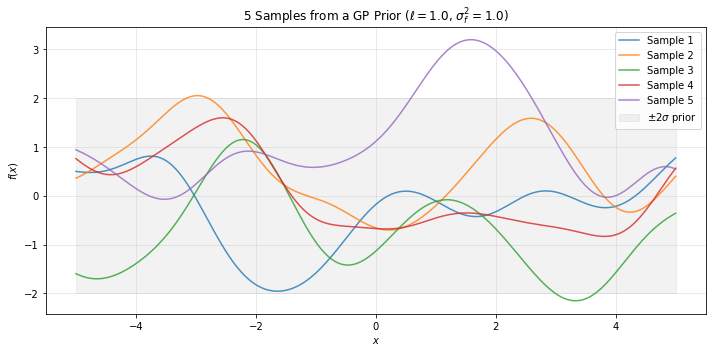

In [3]:
# Sample from GP prior
x_grid = np.linspace(-5, 5, 200).reshape(-1, 1)
K_prior = se_kernel(x_grid, x_grid, length_scale=1.0, signal_var=1.0)
K_prior += 1e-8 * np.eye(len(x_grid))  # numerical stability

L_prior = np.linalg.cholesky(K_prior)

n_samples = 5
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(n_samples):
    u = np.random.randn(len(x_grid))
    f_sample = L_prior @ u
    ax.plot(x_grid, f_sample, alpha=0.8, label=f'Sample {i+1}')

ax.fill_between(x_grid.ravel(), -2, 2, alpha=0.1, color='gray', label='$\\pm 2\\sigma$ prior')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('5 Samples from a GP Prior ($\\ell=1.0$, $\\sigma_f^2=1.0$)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## GP Posterior: Conditioning on Observations

Given training data $\mathcal{D} = \{(x_i, f_i)\}_{i=1}^N$ and test points $X_*$, the posterior is:

$$\mu_* = K_*^\top K^{-1} \mathbf{f}$$
$$\Sigma_* = K_{**} - K_*^\top K^{-1} K_*$$

where $K = k(X, X)$, $K_* = k(X, X_*)$, $K_{**} = k(X_*, X_*)$.

We use the Cholesky decomposition for numerical stability.

In [4]:
def gp_predict(X_train, y_train, X_test, length_scale=1.0, signal_var=1.0, noise_var=1e-8):
    """GP posterior mean and variance using Cholesky decomposition.
    
    Args:
        X_train: (N, d) training inputs
        y_train: (N,) training targets
        X_test: (M, d) test inputs
        length_scale, signal_var: kernel hyperparameters
        noise_var: observation noise variance
    Returns:
        mu: (M,) posterior mean
        var: (M,) posterior variance (diagonal of Sigma)
    """
    K = se_kernel(X_train, X_train, length_scale, signal_var) + noise_var * np.eye(len(X_train))
    K_s = se_kernel(X_train, X_test, length_scale, signal_var)
    K_ss = se_kernel(X_test, X_test, length_scale, signal_var)
    
    # Cholesky solve
    L, low = cho_factor(K, lower=True)
    alpha = cho_solve((L, low), y_train)
    v = cho_solve((L, low), K_s)
    
    mu = K_s.T @ alpha
    var = np.diag(K_ss - K_s.T @ v)
    return mu, var

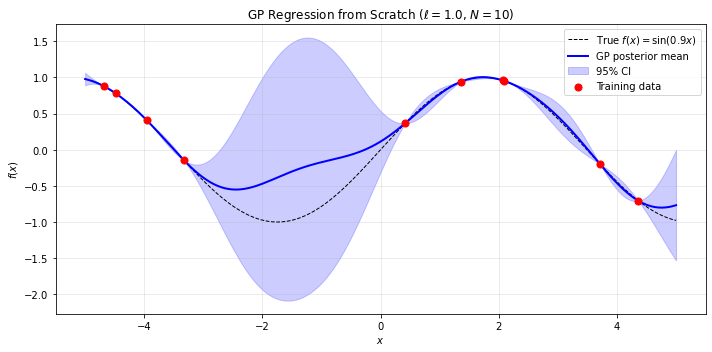

In [5]:
# True function
f_true = lambda x: np.sin(0.9 * x)

# Training data: 10 points
N_train = 10
X_train = np.sort(np.random.uniform(-5, 5, N_train)).reshape(-1, 1)
y_train = f_true(X_train.ravel())

# Test grid
X_test = np.linspace(-5, 5, 300).reshape(-1, 1)

# GP prediction
mu, var = gp_predict(X_train, y_train, X_test, length_scale=1.0, signal_var=1.0)
std = np.sqrt(np.maximum(var, 0))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(X_test, f_true(X_test), 'k--', linewidth=1, label='True $f(x) = \\sin(0.9x)$')
ax.plot(X_test, mu, 'b-', linewidth=2, label='GP posterior mean')
ax.fill_between(X_test.ravel(), mu - 2*std, mu + 2*std, alpha=0.2, color='blue', label='95% CI')
ax.scatter(X_train, y_train, c='red', s=50, zorder=5, label='Training data')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('GP Regression from Scratch ($\\ell=1.0$, $N=10$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Effect of Kernel Parameters

The length scale $\ell$ controls the smoothness of the GP posterior:
- **Small $\ell$**: overfits, wiggly predictions.
- **Optimal $\ell$**: smooth fit through the data.
- **Large $\ell$**: underfits, too smooth.

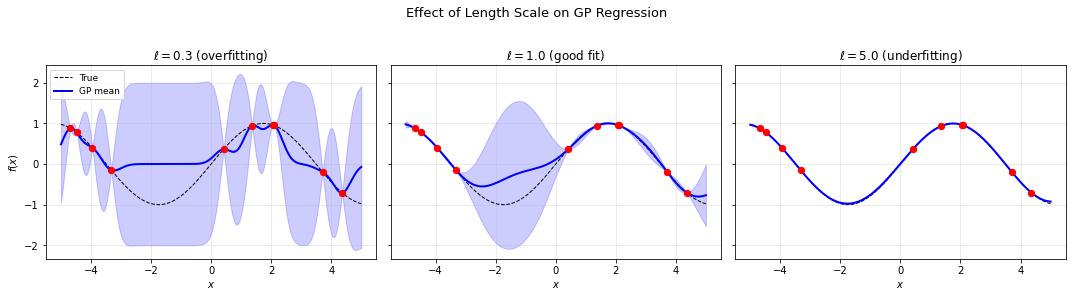

In [6]:
length_scales = [0.3, 1.0, 5.0]
titles = ['$\\ell = 0.3$ (overfitting)', '$\\ell = 1.0$ (good fit)', '$\\ell = 5.0$ (underfitting)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, ls, title in zip(axes, length_scales, titles):
    mu, var = gp_predict(X_train, y_train, X_test, length_scale=ls)
    std = np.sqrt(np.maximum(var, 0))
    
    ax.plot(X_test, f_true(X_test), 'k--', linewidth=1, label='True')
    ax.plot(X_test, mu, 'b-', linewidth=2, label='GP mean')
    ax.fill_between(X_test.ravel(), mu - 2*std, mu + 2*std, alpha=0.2, color='blue')
    ax.scatter(X_train, y_train, c='red', s=40, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$f(x)$')
axes[0].legend(loc='upper left', fontsize=9)
plt.suptitle('Effect of Length Scale on GP Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

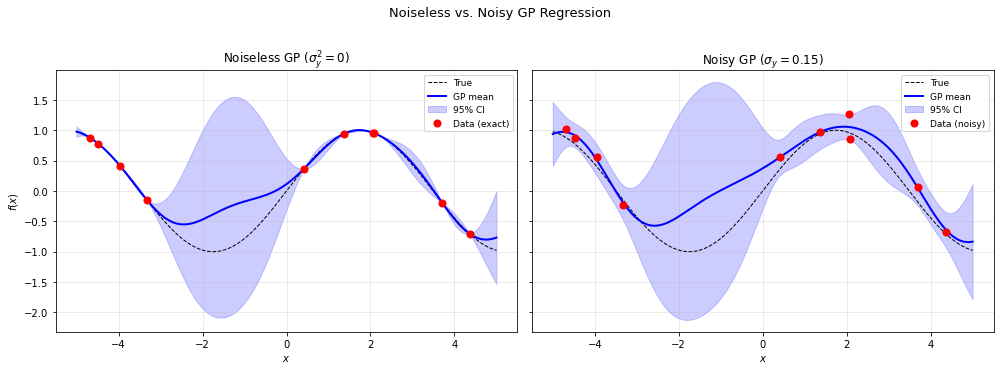

In [7]:
# Noiseless vs Noisy GP regression
# Demonstrates how noise affects the posterior

# Add noise to observations
noise_std = 0.15
y_train_noisy = f_true(X_train.ravel()) + np.random.randn(N_train) * noise_std

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Noiseless
mu_nf, var_nf = gp_predict(X_train, y_train, X_test, length_scale=1.0, noise_var=1e-8)
std_nf = np.sqrt(np.maximum(var_nf, 0))
ax = axes[0]
ax.plot(X_test, f_true(X_test), 'k--', linewidth=1, label='True')
ax.plot(X_test, mu_nf, 'b-', linewidth=2, label='GP mean')
ax.fill_between(X_test.ravel(), mu_nf - 2*std_nf, mu_nf + 2*std_nf, alpha=0.2, color='blue', label='95% CI')
ax.scatter(X_train, y_train, c='red', s=50, zorder=5, label='Data (exact)')
ax.set_title('Noiseless GP ($\\sigma_y^2 = 0$)')
ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Noisy
mu_ny, var_ny = gp_predict(X_train, y_train_noisy, X_test, length_scale=1.0, noise_var=noise_std**2)
std_ny = np.sqrt(np.maximum(var_ny, 0))
ax = axes[1]
ax.plot(X_test, f_true(X_test), 'k--', linewidth=1, label='True')
ax.plot(X_test, mu_ny, 'b-', linewidth=2, label='GP mean')
ax.fill_between(X_test.ravel(), mu_ny - 2*std_ny, mu_ny + 2*std_ny, alpha=0.2, color='blue', label='95% CI')
ax.scatter(X_train, y_train_noisy, c='red', s=50, zorder=5, label='Data (noisy)')
ax.set_title(f'Noisy GP ($\\sigma_y = {noise_std}$)')
ax.set_xlabel('$x$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Noiseless vs. Noisy GP Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

# Part 2: GP Regression with scikit-learn

scikit-learn's `GaussianProcessRegressor` automatically optimizes kernel hyperparameters by maximizing the **marginal likelihood**:

$$\log p(\mathbf{y} | X) = -\frac{1}{2}\mathbf{y}^\top K_y^{-1} \mathbf{y} - \frac{1}{2}\log|K_y| - \frac{N}{2}\log(2\pi)$$

Learned kernel: 1.43**2 * RBF(length_scale=2.57)
Log-marginal-likelihood: 11.303


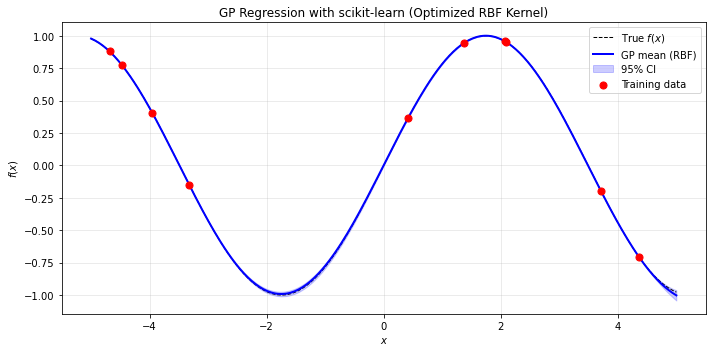

In [8]:
# Fit GP with RBF kernel (automatic hyperparameter optimization)
kernel_rbf = ConstantKernel(1.0) * RBF(length_scale=1.0)
gp_rbf = GaussianProcessRegressor(kernel=kernel_rbf, alpha=1e-8, n_restarts_optimizer=5)
gp_rbf.fit(X_train, y_train)

mu_rbf, std_rbf = gp_rbf.predict(X_test, return_std=True)

print(f"Learned kernel: {gp_rbf.kernel_}")
print(f"Log-marginal-likelihood: {gp_rbf.log_marginal_likelihood_value_:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(X_test, f_true(X_test), 'k--', linewidth=1, label='True $f(x)$')
ax.plot(X_test, mu_rbf, 'b-', linewidth=2, label='GP mean (RBF)')
ax.fill_between(X_test.ravel(), mu_rbf - 2*std_rbf, mu_rbf + 2*std_rbf,
                alpha=0.2, color='blue', label='95% CI')
ax.scatter(X_train, y_train, c='red', s=50, zorder=5, label='Training data')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('GP Regression with scikit-learn (Optimized RBF Kernel)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

RBF kernel:    1.43**2 * RBF(length_scale=2.57)  (LML: 11.303)
Matérn 3/2:   1.07**2 * Matern(length_scale=3.6, nu=1.5)  (LML: 0.909)


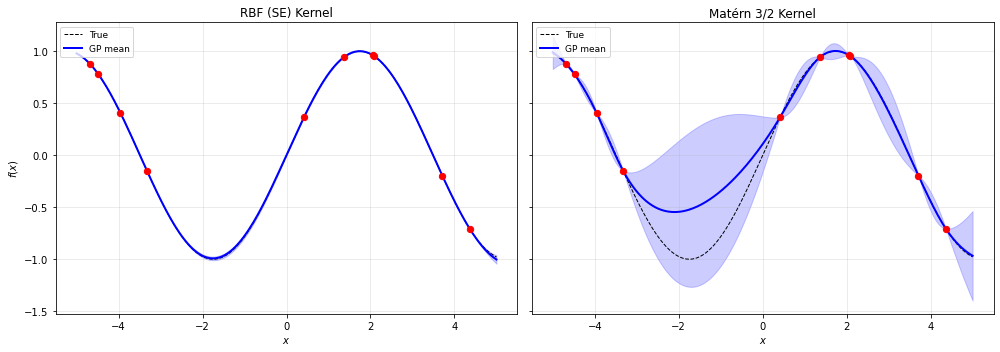

In [9]:
# Compare RBF vs Matern 3/2 kernel
kernel_matern = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5)
gp_matern = GaussianProcessRegressor(kernel=kernel_matern, alpha=1e-8, n_restarts_optimizer=5)
gp_matern.fit(X_train, y_train)

mu_mat, std_mat = gp_matern.predict(X_test, return_std=True)

print(f"RBF kernel:    {gp_rbf.kernel_}  (LML: {gp_rbf.log_marginal_likelihood_value_:.3f})")
print(f"Mat\u00e9rn 3/2:   {gp_matern.kernel_}  (LML: {gp_matern.log_marginal_likelihood_value_:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, mu, std, title in zip(axes,
    [mu_rbf, mu_mat], [std_rbf, std_mat],
    ['RBF (SE) Kernel', 'Mat\u00e9rn 3/2 Kernel']):
    ax.plot(X_test, f_true(X_test), 'k--', linewidth=1, label='True')
    ax.plot(X_test, mu, 'b-', linewidth=2, label='GP mean')
    ax.fill_between(X_test.ravel(), mu - 2*std, mu + 2*std, alpha=0.2, color='blue')
    ax.scatter(X_train, y_train, c='red', s=40, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('$f(x)$')
plt.tight_layout()
plt.show()

/home/simon/.local/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


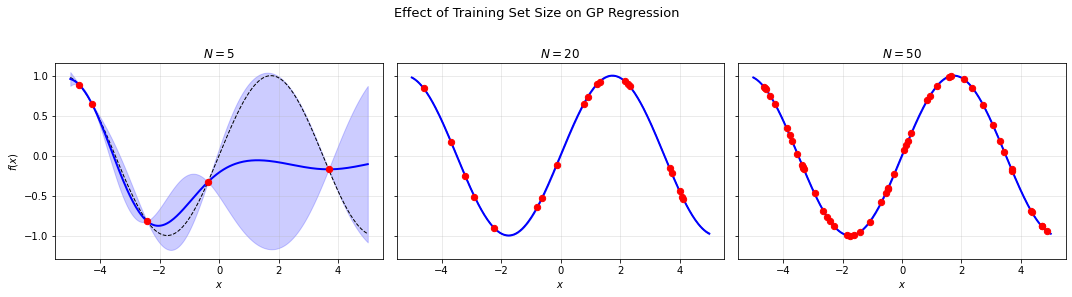

In [10]:
# Effect of training set size: 5, 20, 50 points
n_points_list = [5, 20, 50]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, n_pts in zip(axes, n_points_list):
    X_tr_i = np.sort(np.random.uniform(-5, 5, n_pts)).reshape(-1, 1)
    y_tr_i = f_true(X_tr_i.ravel())
    
    gp_i = GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(1.0), alpha=1e-8, n_restarts_optimizer=3
    )
    gp_i.fit(X_tr_i, y_tr_i)
    mu_i, std_i = gp_i.predict(X_test, return_std=True)
    
    ax.plot(X_test, f_true(X_test), 'k--', linewidth=1)
    ax.plot(X_test, mu_i, 'b-', linewidth=2)
    ax.fill_between(X_test.ravel(), mu_i - 2*std_i, mu_i + 2*std_i, alpha=0.2, color='blue')
    ax.scatter(X_tr_i, y_tr_i, c='red', s=40, zorder=5)
    ax.set_title(f'$N = {n_pts}$')
    ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$f(x)$')
plt.suptitle('Effect of Training Set Size on GP Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

# Part 3: Bayesian Active Learning (BAL)

## Why Active Learning?

When each model evaluation is expensive, we want to choose training points **wisely**. Uniform sampling wastes evaluations in smooth regions.

**Bayesian Active Learning** uses the GP posterior variance to guide point selection:

$$U(x) = w_{\mathrm{exp}} \cdot \mu(x) + \frac{\beta}{2} \log \sigma^2(x)$$

For surrogate building, we often use **pure exploration** ($w_{\mathrm{exp}} = 0$): select the point with highest posterior variance.

In [ ]:
def bal_score(mu, var, w_exp=0.0, beta=1.0):
    """BAL acquisition function.

    U(x) = w_exp * mu(x) + (beta/2) * log(var(x))

    w_exp=0: pure exploration (max variance).
    """
    return w_exp * mu + 0.5 * beta * np.log(np.maximum(var, 1e-30))


def run_bal(f_target, x_candidates, x_init, y_init, n_iterations,
            kernel=None, alpha=1e-8):
    """Run Bayesian Active Learning loop.
    
    Args:
        f_target: function to approximate
        x_candidates: (M, 1) candidate points
        x_init: (n0, 1) initial training inputs
        y_init: (n0,) initial training targets
        n_iterations: number of BAL steps
        kernel: sklearn kernel (default: RBF)
    Returns:
        X_train, y_train: final training set
        history: list of (X_train, y_train, mu, std) at each step
    """
    if kernel is None:
        kernel = ConstantKernel(1.0) * RBF(length_scale=0.3)
    
    X_tr = x_init.copy()
    y_tr = y_init.copy()
    history = []
    
    for i in range(n_iterations):
        gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha, n_restarts_optimizer=2)
        gp.fit(X_tr, y_tr)
        mu, std = gp.predict(x_candidates, return_std=True)
        var = std**2
        
        history.append((X_tr.copy(), y_tr.copy(), mu.copy(), std.copy()))
        
        # Select point with highest variance (pure exploration)
        scores = bal_score(mu, var, w_exp=0.0, beta=1.0)
        idx_best = np.argmax(scores)
        x_new = x_candidates[idx_best:idx_best+1]
        y_new = f_target(x_new.ravel())
        
        X_tr = np.vstack([X_tr, x_new])
        y_tr = np.append(y_tr, y_new)
    
    # Final fit
    gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha, n_restarts_optimizer=2)
    gp.fit(X_tr, y_tr)
    mu, std = gp.predict(x_candidates, return_std=True)
    history.append((X_tr.copy(), y_tr.copy(), mu.copy(), std.copy()))
    
    return X_tr, y_tr, history

In [12]:
# Target function: |sin(pi*x/2)| -- has kinks at x = 0, +/-2
f_bal = lambda x: np.abs(np.sin(np.pi * x / 2))

# Candidate set (dense grid)
x_cand = np.linspace(-3, 3, 500).reshape(-1, 1)
f_cand = f_bal(x_cand.ravel())

# Initial training set: 2 boundary points
X_init = np.array([[-3.0], [3.0]])
y_init = f_bal(X_init.ravel())

# Run BAL for 15 iterations
X_bal, y_bal, bal_history = run_bal(
    f_bal, x_cand, X_init, y_init, n_iterations=15,
    kernel=ConstantKernel(1.0) * RBF(length_scale=0.5)
)

print(f"BAL finished: {len(X_bal)} training points")

BAL finished: 17 training points


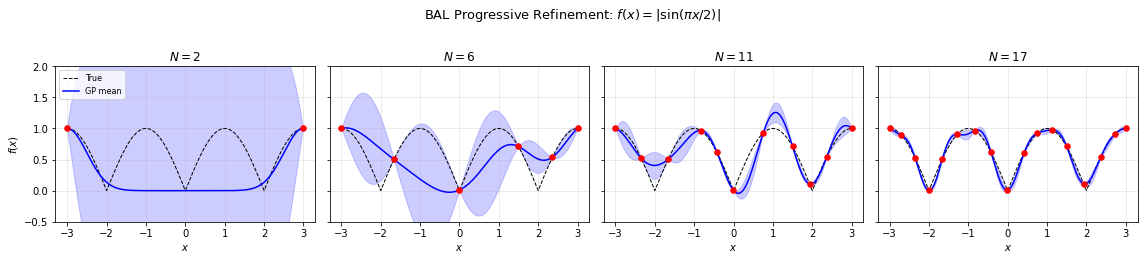

In [13]:
# Visualize BAL progression (every 3rd step)
steps_to_show = [0, 4, 9, 15]  # indices into history

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, step_idx in zip(axes, steps_to_show):
    X_tr_s, y_tr_s, mu_s, std_s = bal_history[step_idx]
    
    ax.plot(x_cand, f_cand, 'k--', linewidth=1, label='True')
    ax.plot(x_cand, mu_s, 'b-', linewidth=1.5, label='GP mean')
    ax.fill_between(x_cand.ravel(), mu_s - 2*std_s, mu_s + 2*std_s,
                    alpha=0.2, color='blue')
    ax.scatter(X_tr_s, y_tr_s, c='red', s=30, zorder=5)
    ax.set_title(f'$N = {len(X_tr_s)}$')
    ax.set_xlabel('$x$')
    ax.set_ylim(-0.5, 2.0)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$f(x)$')
axes[0].legend(loc='upper left', fontsize=8)
plt.suptitle('BAL Progressive Refinement: $f(x) = |\\sin(\\pi x / 2)|$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

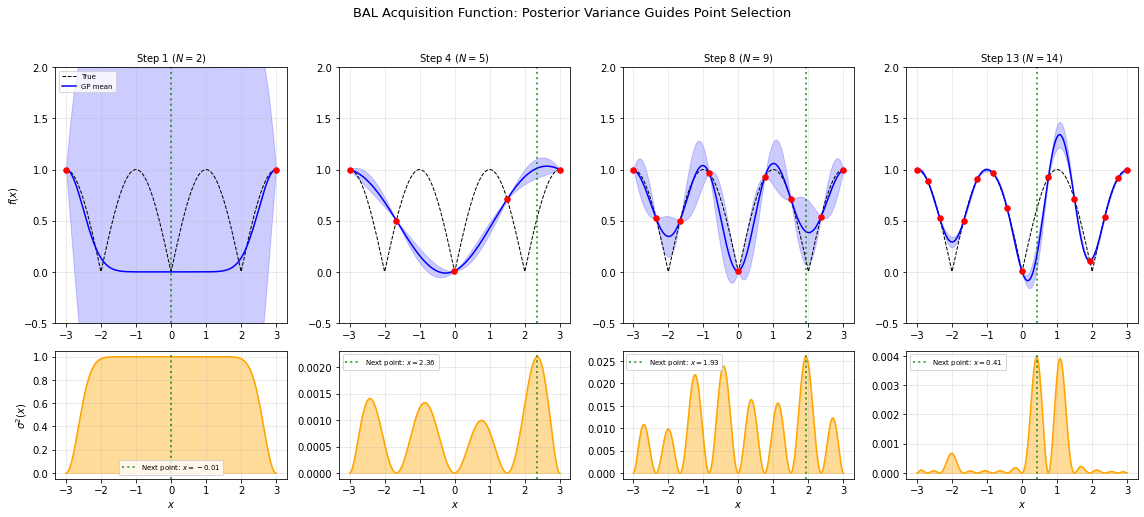

In [14]:
# Visualize the acquisition function (posterior variance) at selected BAL steps
# This shows WHERE and WHY BAL selects each new point

steps_to_show = [0, 3, 7, 12]
fig, axes = plt.subplots(2, 4, figsize=(16, 7), gridspec_kw={'height_ratios': [2, 1]})

for col, step_idx in enumerate(steps_to_show):
    X_tr_s, y_tr_s, mu_s, std_s = bal_history[step_idx]
    var_s = std_s**2
    
    # Top row: GP fit
    ax = axes[0, col]
    ax.plot(x_cand, f_cand, 'k--', linewidth=1, label='True')
    ax.plot(x_cand, mu_s, 'b-', linewidth=1.5, label='GP mean')
    ax.fill_between(x_cand.ravel(), mu_s - 2*std_s, mu_s + 2*std_s,
                    alpha=0.2, color='blue')
    ax.scatter(X_tr_s, y_tr_s, c='red', s=30, zorder=5)
    # Mark the next point to be selected (max variance)
    idx_next = np.argmax(var_s)
    ax.axvline(x_cand[idx_next], color='green', linestyle=':', linewidth=2, alpha=0.7)
    ax.set_title(f'Step {step_idx+1} ($N={len(X_tr_s)}$)', fontsize=10)
    ax.set_ylim(-0.5, 2.0)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel('$f(x)$')
        ax.legend(fontsize=7, loc='upper left')
    
    # Bottom row: posterior variance (acquisition function)
    ax = axes[1, col]
    ax.fill_between(x_cand.ravel(), 0, var_s, alpha=0.4, color='orange')
    ax.plot(x_cand, var_s, 'orange', linewidth=1.5)
    ax.axvline(x_cand[idx_next], color='green', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Next point: $x={x_cand[idx_next,0]:.2f}$')
    ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    if col == 0:
        ax.set_ylabel('$\\sigma^2(x)$')

plt.suptitle('BAL Acquisition Function: Posterior Variance Guides Point Selection', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

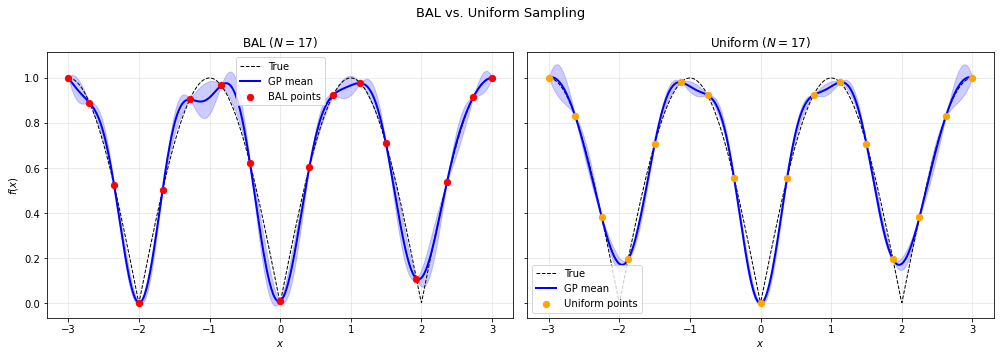

In [15]:
# Uniform sampling baseline with same budget
n_total = len(X_bal)
X_uniform = np.linspace(-3, 3, n_total).reshape(-1, 1)
y_uniform = f_bal(X_uniform.ravel())

gp_uniform = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * RBF(length_scale=0.5),
    alpha=1e-8, n_restarts_optimizer=2
)
gp_uniform.fit(X_uniform, y_uniform)
mu_unif, std_unif = gp_uniform.predict(x_cand, return_std=True)

# BAL final GP
gp_bal_final = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * RBF(length_scale=0.5),
    alpha=1e-8, n_restarts_optimizer=2
)
gp_bal_final.fit(X_bal, y_bal)
mu_bal_final, std_bal_final = gp_bal_final.predict(x_cand, return_std=True)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax = axes[0]
ax.plot(x_cand, f_cand, 'k--', linewidth=1, label='True')
ax.plot(x_cand, mu_bal_final, 'b-', linewidth=2, label='GP mean')
ax.fill_between(x_cand.ravel(), mu_bal_final - 2*std_bal_final,
                mu_bal_final + 2*std_bal_final, alpha=0.2, color='blue')
ax.scatter(X_bal, y_bal, c='red', s=40, zorder=5, label='BAL points')
ax.set_title(f'BAL ($N={n_total}$)')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x_cand, f_cand, 'k--', linewidth=1, label='True')
ax.plot(x_cand, mu_unif, 'b-', linewidth=2, label='GP mean')
ax.fill_between(x_cand.ravel(), mu_unif - 2*std_unif,
                mu_unif + 2*std_unif, alpha=0.2, color='blue')
ax.scatter(X_uniform, y_uniform, c='orange', s=40, zorder=5, label='Uniform points')
ax.set_title(f'Uniform ($N={n_total}$)')
ax.set_xlabel('$x$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('BAL vs. Uniform Sampling', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Convergence comparison: MAE vs number of training points
budgets = range(3, 26)
mae_bal_list = []
mae_unif_list = []

for seed_idx, n_pts in enumerate(budgets):
    # Reseed inside the loop so each BAL run is reproducible
    np.random.seed(SEED + seed_idx)
    # BAL
    n_iters = n_pts - 2  # start from 2 initial points
    if n_iters < 1:
        n_iters = 1
    X_b, y_b, _ = run_bal(
        f_bal, x_cand, X_init, y_init, n_iterations=n_iters,
        kernel=ConstantKernel(1.0) * RBF(length_scale=0.5)
    )
    gp_b = GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(length_scale=0.5),
        alpha=1e-8, n_restarts_optimizer=1
    )
    gp_b.fit(X_b[:n_pts], y_b[:n_pts])
    mu_b = gp_b.predict(x_cand)
    mae_bal_list.append(np.mean(np.abs(mu_b - f_cand)))
    
    # Uniform
    X_u = np.linspace(-3, 3, n_pts).reshape(-1, 1)
    y_u = f_bal(X_u.ravel())
    gp_u = GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(length_scale=0.5),
        alpha=1e-8, n_restarts_optimizer=1
    )
    gp_u.fit(X_u, y_u)
    mu_u = gp_u.predict(x_cand)
    mae_unif_list.append(np.mean(np.abs(mu_u - f_cand)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(list(budgets), mae_bal_list, 'bo-', linewidth=2, markersize=5, label='BAL')
ax.semilogy(list(budgets), mae_unif_list, 'rs--', linewidth=2, markersize=5, label='Uniform')
ax.set_xlabel('Number of training points $N$')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Convergence: BAL vs. Uniform Sampling')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

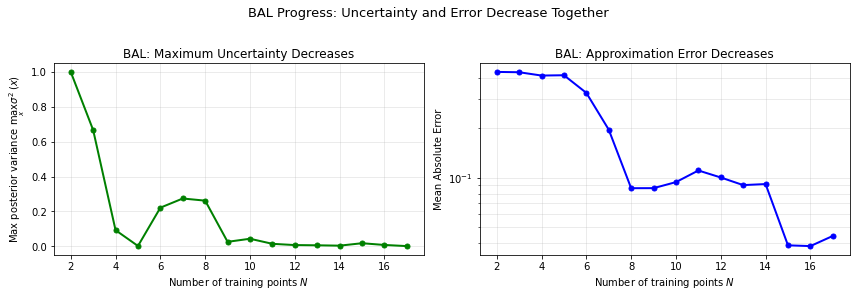

In [17]:
# Track maximum posterior variance and MAE across BAL iterations
# Shows how uncertainty and error decrease together

max_var_history = []
mae_history = []
for step_idx in range(len(bal_history)):
    _, _, mu_h, std_h = bal_history[step_idx]
    max_var_history.append(np.max(std_h**2))
    mae_history.append(np.mean(np.abs(mu_h - f_cand)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(2, 2 + len(max_var_history)), max_var_history, 'go-', linewidth=2, markersize=5)
ax.set_xlabel('Number of training points $N$')
ax.set_ylabel('Max posterior variance $\\max_x \\sigma^2(x)$')
ax.set_title('BAL: Maximum Uncertainty Decreases')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(range(2, 2 + len(mae_history)), mae_history, 'bo-', linewidth=2, markersize=5)
ax.set_xlabel('Number of training points $N$')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('BAL: Approximation Error Decreases')
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('BAL Progress: Uncertainty and Error Decrease Together', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## Summary

### Key takeaways

1. **Gaussian Processes** provide a principled nonparametric Bayesian approach to regression with **built-in uncertainty quantification**.
2. The **kernel** encodes prior beliefs about function smoothness. Hyperparameters are learned by maximizing the **marginal likelihood**.
3. **Bayesian Active Learning (BAL)** leverages the GP posterior variance to intelligently select training points, achieving faster convergence than uniform sampling — especially for functions with kinks or local features.
4. **Limitation**: GPs scale as $O(N^3)$, making them best suited for moderate-dimensional problems ($d \leq 10$) with modest training sets ($N \leq 10^4$).

### References

- Rasmussen & Williams (2006), *Gaussian Processes for Machine Learning*, MIT Press.
- Renner & Scheidegger (2018), *Machine Learning for Dynamic Incentive Problems*.
- Kübler, Scheidegger & Surbek (2026), *Globally Optimal Policies*, J. Political Economy: Macro.

## Takeaway

GPs deliver calibrated uncertainty (95% credible bands) at the cost of $\\mathcal{O}(n^3)$ inference; Bayesian active learning closes the loop by directing the next sample to the maximum-variance point. On the |sin| target, BAL reaches the same RMSE as uniform sampling in roughly half the evaluations — the headline economic payoff is in §9.4 and the GP-VFI loop of NB 04.


In [ ]:
# Smoke-mode validation: at the largest budget the BAL GP should approximate f reasonably well
# and stay competitive with the uniform design. Loose tolerances; tighten in teaching/production.
if RUN_MODE == 'smoke':
    assert mae_bal_list[-1] < 0.1, f'BAL GP MAE too large at full budget: {mae_bal_list[-1]:.3e}'
    assert mae_bal_list[-1] <= 3.0 * mae_unif_list[-1], (
        f'BAL no longer competitive with uniform: BAL {mae_bal_list[-1]:.3e} vs uniform {mae_unif_list[-1]:.3e}'
    )
